# **Análisis de Sentimientos y Análisis de Redes Semánticas Aplicado a Tweets LGBTIQ+**

## Carlos Francisco Carreras De León


**Descarga de librerías:**

In [1]:
import pandas as pd

**Carga del conjunto de datos LGBT Tweets:**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
csv_path = "/content/drive/MyDrive/LGBT_Tweets_processed.csv"
df = pd.read_csv(csv_path)
df

,Unnamed: 0,date,time,id,tweet,language,replies_count,retweets_count,likes_count
0,0,2022-08-26,10:31:10,1562991009180827649,Praying for my lgbt Nigerians 🙏🏽🙏🏽🙏🏽,en,0,0,0
1,1,2022-08-26,10:31:02,1562990976939229184,@yanmisamm So pass agg omg you really are lgbt,en,0,0,0
2,3,2022-08-26,10:30:59,1562990965442326528,@ChampionExcel @watokohom @MrAndyNgo @football...,en,0,0,0
3,7,2022-08-26,10:30:34,1562990860928659457,To be clear it doesn't justify what the LGBT c...,en,0,0,0
4,10,2022-08-26,10:30:24,1562990819485032449,good night lgbt community https://t.co/0PAMOU...,en,1,0,2
...,...,...,...,...,...,...,...,...,...
32451,99995,2022-08-21,00:09:11,1561022541833068545,@i664k @birdofterror4 @st1mmer @cringepolitik ...,en,0,1,1
32452,99997,2022-08-21,00:09:06,1561022522933616642,@Comrade4568 I`m anti-trans and anti-lgbt,en,1,0,1
32453,100009,2022-08-21,00:07:52,1561022211405881344,#Lgbt #lgbtq #lgbtqiaplus #lgbtqcommunity #lgb...,en,0,0,0
32454,100010,2022-08-21,00:07:50,1561022206167187456,Man its no fucking wonder why it's so hard for...,en,1,0,0


# Preprocesamiento de Datos

**Verificar si hay valores perdidos:**

In [5]:
missing_values = df.isnull().sum()
display(missing_values[missing_values > 0])

if (missing_values > 0).any():
    print("\nHay valores perdidos en el dataset.")
else:
    print("\nNo hay valores perdidos en el dataset.")

,0



No hay valores perdidos en el dataset.


**Consulta de los tipos de datos y variables que contiene el data set:**

In [6]:
df.dtypes

,0
Unnamed: 0,int64
date,object
time,object
id,int64
tweet,object
language,object
replies_count,int64
retweets_count,int64
likes_count,int64


**Cambiar el atributo "date" al formato datetime y "time" al formato datetime (horas:minutos:segundos)**


In [7]:
df['date'] = pd.to_datetime(df['date'])
df['time'] = pd.to_datetime(df['time'], format='%H:%M:%S').dt.time

**Verificar si se aplicó correctamente la transformación al tipo de datos indicado:**

In [8]:
df.dtypes

,0
Unnamed: 0,int64
date,datetime64[ns]
time,object
id,int64
tweet,object
language,object
replies_count,int64
retweets_count,int64
likes_count,int64


**Creación de variable de la hora que se publicó el tweet:**

In [9]:
df['tweet_hour'] = df['time'].apply(lambda x: x.hour)

# Análisis Exploratorio

**Crear un gráfico de línea que muestre la frecuencia de tweets por hora para cada día en el período del 21 al 26 de agosto de 2022:**


In [10]:
# Agrupar el data frame por 'date' y 'tweet_hour' para contar la frecuencia de tweets para cada hora de cada día

daily_hourly_tweet_counts = df.groupby(['date', 'tweet_hour']).size()
print("Frecuencia de tweets por hora y día para el período filtrado:")
print(daily_hourly_tweet_counts.head(10))

Frecuencia de tweets por hora y día para el período filtrado:
date        tweet_hour
2022-08-21  0             202
            1             230
            2             271
            3             229
            4             236
            5             240
            6             231
            7             201
            8             203
            9             176
dtype: int64


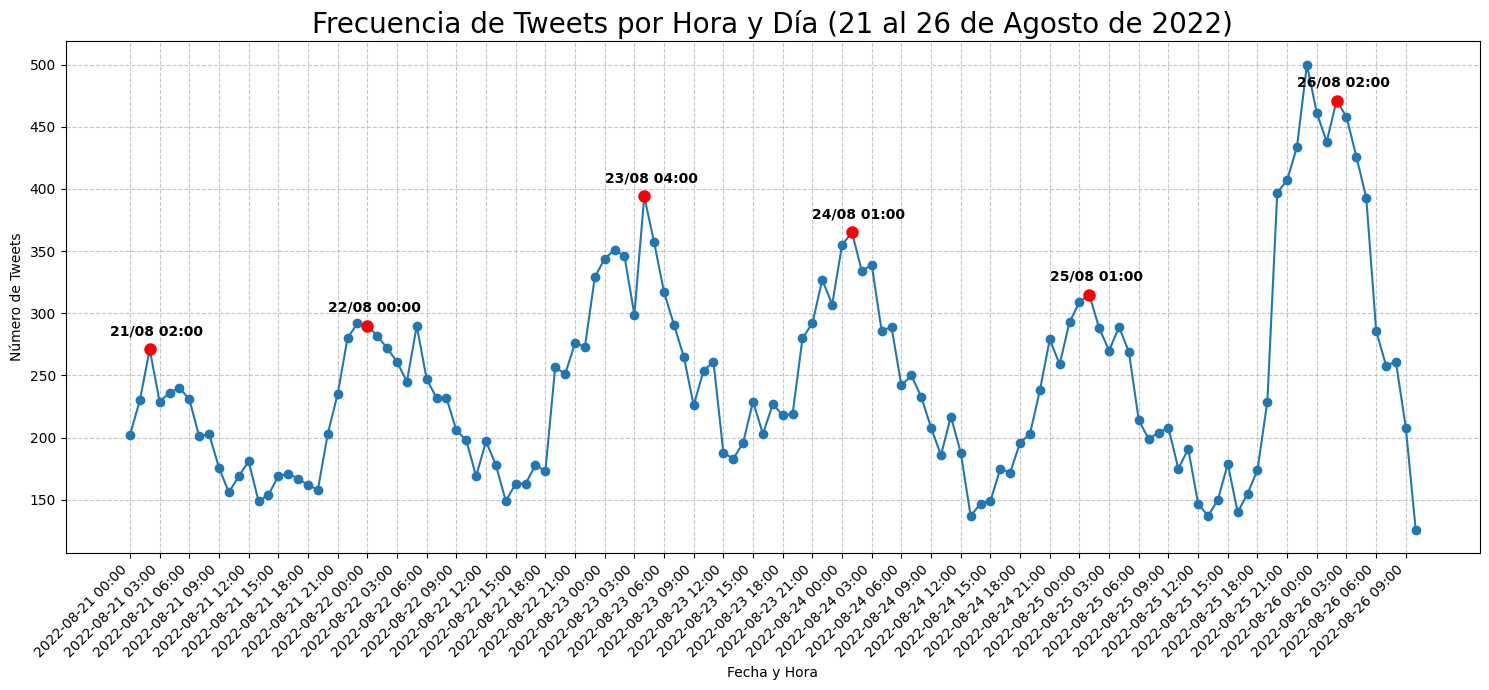

In [11]:
# Importar librería de visualización de datos
import matplotlib.pyplot as plt

# Configurar gráfico de línea
plt.figure(figsize=(15, 7))
ax = daily_hourly_tweet_counts.plot(kind='line', marker='o', linestyle='-')
plt.title('Frecuencia de Tweets por Hora y Día (21 al 26 de Agosto de 2022)',fontsize=20)
plt.xlabel('Fecha y Hora')
plt.ylabel('Número de Tweets')

# Generar ticks y etiquetas para cada 3 horas, alineados con los datos existentes
tick_positions = []
tick_labels = []

for i, (date, hour) in enumerate(daily_hourly_tweet_counts.index):
    if hour % 3 == 0:
        tick_positions.append(i) # Usar el índice posicional de los datos
        tick_labels.append(f'{date.strftime("%Y-%m-%d")} {hour:02d}:00')

plt.xticks(tick_positions, tick_labels, rotation=45, ha='right') # Establecer ticks y etiquetas

# Puntos específicos a resaltar en rojo
points_to_highlight = [
    (pd.to_datetime('2022-08-21').date(), 2),
    (pd.to_datetime('2022-08-22').date(), 0),
    (pd.to_datetime('2022-08-23').date(), 4),
    (pd.to_datetime('2022-08-24').date(), 1),
    (pd.to_datetime('2022-08-25').date(), 1),
    (pd.to_datetime('2022-08-26').date(), 2)
]

# Resaltar los puntos específicos en rojo y añadir etiquetas
for i, ((date_idx, hour_idx), count) in enumerate(daily_hourly_tweet_counts.items()):
    # Convertir date_idx a date object para comparar con points_to_highlight
    if (date_idx.date(), hour_idx) in points_to_highlight:
        ax.plot(i, count, 'ro', markersize=8)
        label = f'{date_idx.strftime("%d/%m")} {hour_idx:02d}:00'
        ax.annotate(label, (i, count), textcoords="offset points", xytext=(5,10), ha='center', fontsize=10, fontweight='bold') # Increased vertical offset in xytext

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Se observa un patrón diario claro en la actividad de los tweets. Generalmente, la frecuencia de tweets tiende a ser más alta en las primeras horas de la madrugada (0-4 AM), lo que sugiere que la audiencia está más activa, y disminuye durante el día, con posibles repuntes en la tarde o noche.



# Análisis de sentimientos con VADER

In [12]:
# Instalación de librerías
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00


In [13]:
# Descarga de librerías
import re
import string
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [14]:
text_column = "tweet"

# Preparar recursos
analyzer = SentimentIntensityAnalyzer()

# Preprocesamiento actualizado para incluir la eliminación de emojis
def preprocess_tweet(tweet):
    # Convertir a string por si hay NaN
    tweet = str(tweet)

    # Eliminar URLs
    tweet = re.sub(r"http\S+|www\S+|https\S+", "", tweet)

    # Eliminar menciones (@usuario)
    tweet = re.sub(r"@\w+", "", tweet)

    # Eliminar símbolo # pero mantener la palabra
    tweet = re.sub(r"#", "", tweet)

    # Eliminar números
    tweet = re.sub(r"\d+", "", tweet)

    # Eliminar espacios extra
    tweet = tweet.strip()

    return tweet

# Aplicar preprocesamiento con la nueva función a la columna 'tweet'
df["clean_tweet"] = df["tweet"].apply(preprocess_tweet)

In [15]:
# Definir funcion de análisis de sentimiento con VADER
def get_sentiment(tweet):
    scores = analyzer.polarity_scores(tweet)
    compound = scores["compound"]

    # Regla estándar VADER
    if compound >= 0.05:
        return "positivo"
    elif compound <= -0.05:
        return "negativo"
    else:
        return "neutral"

df["sentimiento"] = df["clean_tweet"].apply(get_sentiment)

In [16]:
# Conteo y porcentaje de tweets según el tipo de sentimiento
sentimiento_counts = df['sentimiento'].value_counts()
sentimiento_percentages = df['sentimiento'].value_counts(normalize=True) * 100

sentimiento_summary = pd.DataFrame({
    'Tweets': sentimiento_counts,
    'Porcentaje (%)': sentimiento_percentages
})

display(sentimiento_summary)

,Tweets,Porcentaje (%)
sentimiento,,
positivo,14194,43.733054
negativo,12079,37.216539
neutral,6183,19.050407


De un total de 32,456 tweets con el hashtag LGBT: el 43.7% fueron positivos, el 37.2% negativos y 19.1% neutrales.

**Validación de VADER filtrando los cinco tweets más positivos y los más negativos:**

In [17]:
# Definir función
def get_compound_score(tweet):
    return analyzer.polarity_scores(tweet)['compound']

# Añadir columna 'sentiment_score' al data frame con el puntaje generado por VADER
df['sentiment_score'] = df['clean_tweet'].apply(get_compound_score)
print("La columna 'sentiment_score' ha sido añadida al DataFrame.")

La columna 'sentiment_score' ha sido añadida al DataFrame.


**Cinco tweets más positivos:**

In [18]:
most_positive_tweets = df.sort_values(by='sentiment_score', ascending=False).head(5)
print("Los 5 tweets más positivos:")
display(most_positive_tweets[['clean_tweet', 'sentiment_score']])

Los 5 tweets más positivos:


,clean_tweet,sentiment_score
31907,❤🧡💛💚💙💜🤎🖤🤍❤🧡💛💚💙💜🤎🖤🤍❤🧡💛💚💙💜🤎🖤❤🧡💛💚💙💜🤎🖤🤍❤🧡💛💚💙💜🤎🖤🤍❤🧡...,0.9999
13454,hunter schafer not understanding that nonbinar...,0.9994
21522,–MORE EPISODES ADDED TO THE OWL HOUSE SEASON !...,0.9954
7898,DaniGray Throwback loveneverfollowstherules mm...,0.9928
14699,"this is true, but I think sometimes people mis...",0.9922


**Cinco tweets más negativos:**


In [19]:
most_negative_tweets = df.sort_values(by='sentiment_score', ascending=True).head(5)
print("Los 5 tweets más negativos:")
display(most_negative_tweets[['clean_tweet', 'sentiment_score']])

Los 5 tweets más negativos:


,clean_tweet,sentiment_score
349,“lgbt dress attire” but you miss out the hyper...,-0.9993
4801,BLOODBORNE X GUTTER PRAYER It's said the deepe...,-0.9929
7182,REMINDER: REPUBLICANS HATE WOMEN. REPUBLICANS ...,-0.9910
25274,"Causing poverty, hunger, racism, hate, domesti...",-0.9897
27818,The difference is that while Jews are an ethni...,-0.9867


**Visualización en gráfico de líneas los tweets positivos, negativos y neutrales por hora y día:**


In [20]:
# Agrupar la frecuencia de tweets por día, hora y tipo de sentimiento
sentiment_time_series = df.groupby(['date', 'tweet_hour', 'sentimiento']).size()
sentiment_time_series_unstacked = sentiment_time_series.unstack(fill_value=0)

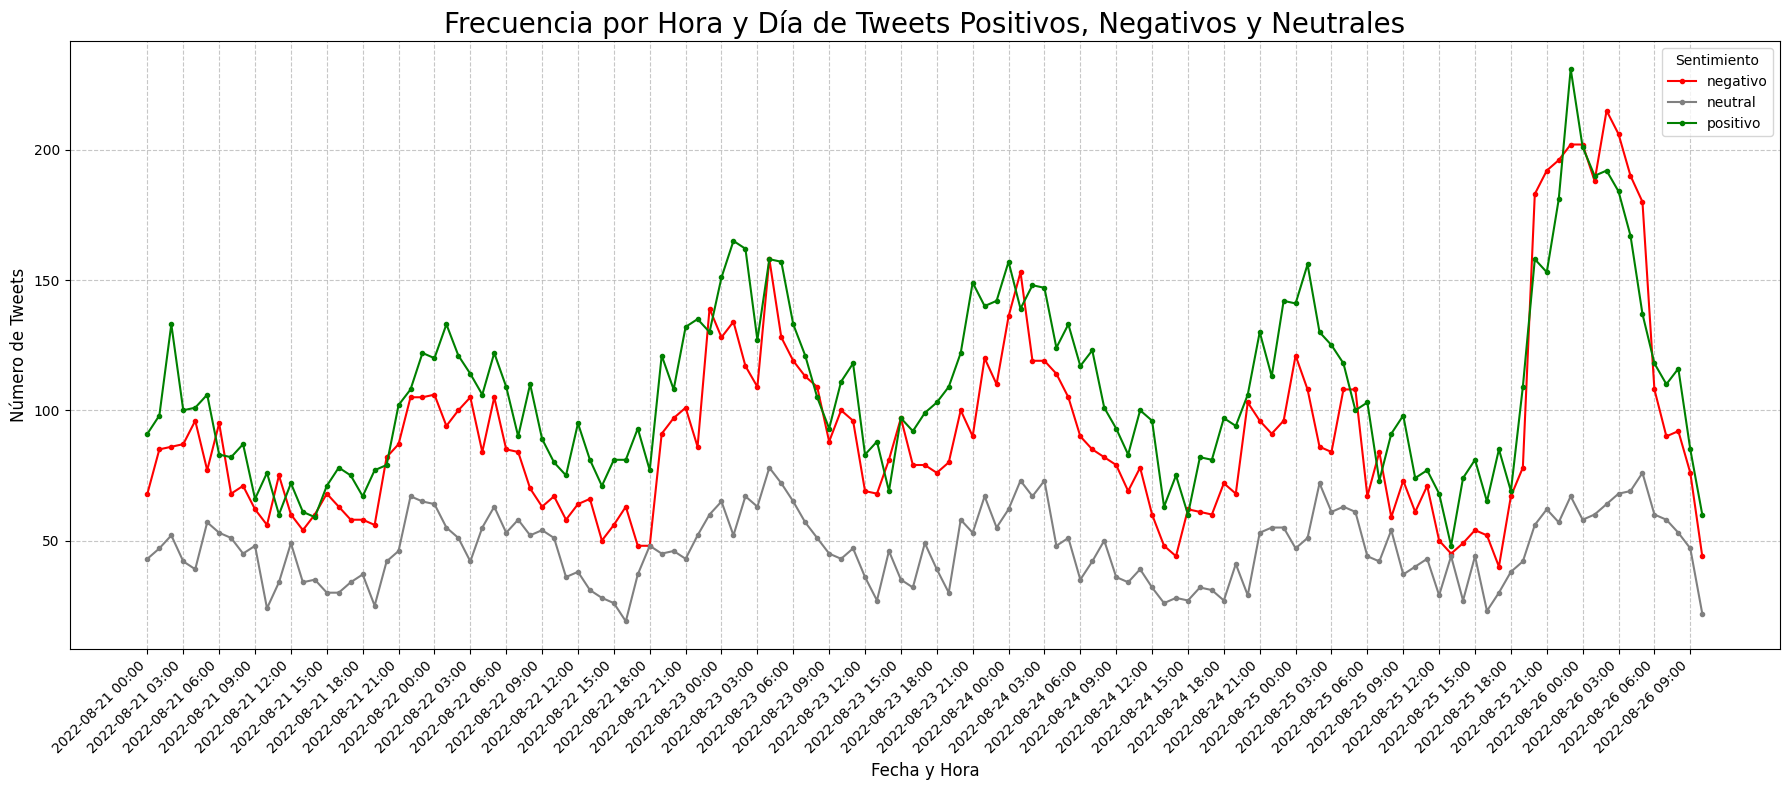

In [21]:
import matplotlib.pyplot as plt

# Definir un diccionario de color para cada sentimiento
colors = {'positivo': 'green', 'neutral': 'gray', 'negativo': 'red'}

plt.figure(figsize=(18, 8))
sentiment_time_series_unstacked.plot(kind='line', ax=plt.gca(), marker='o', markersize=3, color=[colors[col] for col in sentiment_time_series_unstacked.columns])

plt.title('Frecuencia por Hora y Día de Tweets Positivos, Negativos y Neutrales', fontsize=20)
plt.xlabel('Fecha y Hora', fontsize=12)
plt.ylabel('Número de Tweets', fontsize=12)

# Generar ticks y etiquetas para cada 3 horas, alineados con los datos existentes
tick_positions = []
tick_labels = []

for i, (date, hour) in enumerate(sentiment_time_series_unstacked.index):
    if hour % 3 == 0:
        tick_positions.append(i) # Usar el índice posicional de los datos
        tick_labels.append(f'{date.strftime("%Y-%m-%d")} {hour:02d}:00')

plt.xticks(tick_positions, tick_labels, rotation=45, ha='right') # Establecer ticks y etiquetas

plt.legend(title='Sentimiento')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Métricas de Engagement

**Cinco Tweets con más Likes:**

In [22]:
most_liked_tweets = df.sort_values(by='likes_count', ascending=False).head(5)
print("Los 5 tweets con más likes:")
display(most_liked_tweets[['clean_tweet', 'likes_count', 'sentimiento']])

Los 5 tweets con más likes:


,clean_tweet,likes_count,sentimiento
10023,lgbt fashion spectrum,68613,neutral
27681,Andrew Tate has groomed more children in like ...,54263,positivo
21221,Would you vote for an LGBT candidate for Presi...,21398,positivo
19231,Give me thumbs up and retweet if LGBT is welco...,12738,positivo
18623,Give me thumbs up and retweet if LGBT is welco...,9340,positivo


**Cinco Tweets con más Retweets:**

In [23]:
most_retweeted_tweets = df.sort_values(by='retweets_count', ascending=False).head(5)
print("Los 5 tweets con más retweets:")
display(most_retweeted_tweets[['clean_tweet', 'retweets_count', 'sentimiento']])

Los 5 tweets con más retweets:


,clean_tweet,retweets_count,sentimiento
10023,lgbt fashion spectrum,9141,neutral
27681,Andrew Tate has groomed more children in like ...,5941,positivo
19231,Give me thumbs up and retweet if LGBT is welco...,4121,positivo
18623,Give me thumbs up and retweet if LGBT is welco...,3042,positivo
29257,Just replace the word “woke” with “black peopl...,2540,negativo


**Cinco Tweets con más Replies:**

In [24]:
most_replied_tweets = df.sort_values(by='replies_count', ascending=False).head(5)
print("Los 5 tweets con más respuestas:")
display(most_replied_tweets[['clean_tweet', 'replies_count', 'sentimiento']])

Los 5 tweets con más respuestas:


,clean_tweet,replies_count,sentimiento
21221,Would you vote for an LGBT candidate for Presi...,7051,positivo
19231,Give me thumbs up and retweet if LGBT is welco...,3381,positivo
18623,Give me thumbs up and retweet if LGBT is welco...,2689,positivo
21961,I’m actually quite pleased todays complaints a...,922,negativo
20856,Transgenders SHOCKED that they SUPPORT Ukraine...,547,negativo


**Extracción de menciones en los tweets:**


In [25]:
import re

# Definir función de extracción de menciones @ para luego crear una nueva columna con el listado de menciones
def extract_mentions(tweet):
    tweet = str(tweet)
    mentions = re.findall(r'@\w+', tweet)
    return mentions

df['mentions_list'] = df['tweet'].apply(extract_mentions)
print("La columna 'mentions_list' ha sido creada con las menciones extraídas.")

display(df[['tweet', 'mentions_list']].head())

La columna 'mentions_list' ha sido creada con las menciones extraídas.


,tweet,mentions_list
0,Praying for my lgbt Nigerians 🙏🏽🙏🏽🙏🏽,[]
1,@yanmisamm So pass agg omg you really are lgbt,[@yanmisamm]
2,@ChampionExcel @watokohom @MrAndyNgo @football...,"[@ChampionExcel, @watokohom, @MrAndyNgo, @foot..."
3,To be clear it doesn't justify what the LGBT c...,[]
4,good night lgbt community https://t.co/0PAMOU...,[]


In [26]:
from collections import Counter

# Convertir la lista de listas de las menciones en una sola lista
all_mentions = [mention for sublist in df['mentions_list'] for mention in sublist]

# Contar la frecuencia de cada mención
mention_counts = Counter(all_mentions)

# Las 10 menciones más frecuentes
top_10_mentions = mention_counts.most_common(10)

print("Los 10 usuarios más mencionados:")
for mention, count in top_10_mentions:
    print(f"{mention}: {count}")

Los 10 usuarios más mencionados:
@libsoftiktok: 258
@FoxNews: 236
@Sharinberg: 176
@LincsPolice: 156
@againstgrmrs: 123
@IGN: 115
@dicklevitating: 113
@CultureCrave: 111
@KatyMontgomerie: 82
@LGBT: 81


In [27]:
# Desplegar la columna con todas las menciones desagrupadas
mentions_table = pd.DataFrame(all_mentions, columns=['Mention'])
display(mentions_table)

,Mention
0,@yanmisamm
1,@ChampionExcel
2,@watokohom
3,@MrAndyNgo
4,@football_56OL
...,...
40795,@i664k
40796,@birdofterror4
40797,@st1mmer
40798,@cringepolitik


**Extracción de hashtags en los tweets:**

In [28]:
import re
from collections import Counter

def extract_hashtags_for_frequency(tweet):
    tweet = str(tweet) # Ensure tweet is a string
    # Encontrar todos los patrones que empiecen con "#" seguido de letras
    hashtags = re.findall(r'#\w+', tweet.lower())
    return hashtags

# Aplicar la función a la columna tweet  para obtener la lista de listas de hashtags
all_hashtags_lists = df['tweet'].apply(extract_hashtags_for_frequency)

# Convertir la lista de listas en una sola lista de todos los hashtags
all_hashtags = [hashtag for sublist in all_hashtags_lists for hashtag in sublist]

# Contar la frecuencia de cada hashtag
hashtag_counts = Counter(all_hashtags)

# Los 10 hashtags más frecuentes
top_10_hashtags = hashtag_counts.most_common(10)

print("Los 10 hashtags más frecuentes:")
for hashtag, count in top_10_hashtags:
    print(f"{hashtag}: {count}")

Los 10 hashtags más frecuentes:
#lgbt: 5147
#sffpit: 1475
#fa: 671
#a: 659
#lgbtq: 631
#ya: 523
#pride: 343
#gay: 338
#music: 267
#nftcommunity: 242


In [29]:
# Desplegar la columna con todos los hashtags
hashtags_table = pd.DataFrame(all_hashtags, columns=['Hashtag'])
display(hashtags_table)

,Hashtag
0,#lgbt
1,#transisbeautiful
2,#conservative
3,#politics
4,#talkradio
...,...
30250,#lgbt
30251,#lgbtq
30252,#lgbtqiaplus
30253,#lgbtqcommunity


#Análisis de Red de Coocurrencias de Menciones y Hashtags

**Filtrar los tweets positivos del data frame:**

In [30]:
df_positive = df[df['sentimiento'] == 'positivo'].copy()
print("DataFrame 'df_positive' creado con tweets de sentimiento positivo.")

display(df_positive.head())

DataFrame 'df_positive' creado con tweets de sentimiento positivo.


,Unnamed: 0,date,time,id,tweet,language,replies_count,retweets_count,likes_count,tweet_hour,clean_tweet,sentimiento,sentiment_score,mentions_list
0,0,2022-08-26,10:31:10,1562991009180827649,Praying for my lgbt Nigerians 🙏🏽🙏🏽🙏🏽,en,0,0,0,10,Praying for my lgbt Nigerians 🙏🏽🙏🏽🙏🏽,positivo,0.3612,[]
3,7,2022-08-26,10:30:34,1562990860928659457,To be clear it doesn't justify what the LGBT c...,en,0,0,0,10,To be clear it doesn't justify what the LGBT c...,positivo,0.2023,[]
4,10,2022-08-26,10:30:24,1562990819485032449,good night lgbt community https://t.co/0PAMOU...,en,1,0,2,10,good night lgbt community,positivo,0.4404,[]
5,12,2022-08-26,10:30:21,1562990805999964161,Hello guys Im Japanese Filipino who does singi...,en,0,0,0,10,Hello guys Im Japanese Filipino who does singi...,positivo,0.9521,[]
6,13,2022-08-26,10:30:17,1562990786483957766,@SmokeySmoker @Nope_Im_Outski @FOX5Vegas BLM a...,en,0,0,0,10,BLM and LGBT groups do a better job supporting...,positivo,0.7003,"[@SmokeySmoker, @Nope_Im_Outski, @FOX5Vegas]"


**Extracción de menciones y hashtags de los tweets positivos:**


In [31]:
from collections import Counter

# Aplicar la función extract_mentions a la columna 'tweet' del DataFrame df_positive
df_positive['mentions_list_positive'] = df_positive['tweet'].apply(extract_mentions)

# Aplicar la función extract_hashtags_for_frequency a la columna 'tweet' del DataFrame df_positive
df_positive['hashtags_list_positive'] = df_positive['tweet'].apply(extract_hashtags_for_frequency)

# Aplanar la columna mentions_list_positive y contar la frecuencia
all_mentions_positive = [mention for sublist in df_positive['mentions_list_positive'] for mention in sublist]
mention_counts_positive = Counter(all_mentions_positive)
top_10_positive_mentions = mention_counts_positive.most_common(10)

print("Las 10 menciones más frecuentes en tweets positivos:")
for mention, count in top_10_positive_mentions:
    print(f"{mention}: {count}")

# Aplanar la columna hashtags_list_positive y obtener hashtags únicos
all_hashtags_positive = [hashtag for sublist in df_positive['hashtags_list_positive'] for hashtag in sublist]
unique_positive_hashtags = list(set(all_hashtags_positive))

print(f"\nNúmero de hashtags únicos en tweets positivos: {len(unique_positive_hashtags)}")
print("Primeros 10 hashtags únicos en tweets positivos:", unique_positive_hashtags[:10])


Las 10 menciones más frecuentes en tweets positivos:
@libsoftiktok: 112
@FoxNews: 106
@Sharinberg: 101
@LincsPolice: 64
@amusejanetmason: 60
@CultureCrave: 53
@dicklevitating: 51
@IGN: 50
@againstgrmrs: 48
@tjklune: 38

Número de hashtags únicos en tweets positivos: 4302
Primeros 10 hashtags únicos en tweets positivos: ['#gayfiction', '#pink', '#beanie', '#jenlisa', '#prideontheroad', '#contemporary', '#christofascism', '#championsleague', '#waxmelt', '#sportingprideireland']


**Filtrar los tweets negativos del data frame:**


In [32]:
df_negative = df[df['sentimiento'] == 'negativo'].copy()
print("DataFrame 'df_negative' creado con tweets de sentimiento negativo.")

display(df_negative.head())

DataFrame 'df_negative' creado con tweets de sentimiento negativo.


,Unnamed: 0,date,time,id,tweet,language,replies_count,retweets_count,likes_count,tweet_hour,clean_tweet,sentimiento,sentiment_score,mentions_list
2,3,2022-08-26,10:30:59,1562990965442326528,@ChampionExcel @watokohom @MrAndyNgo @football...,en,0,0,0,10,"Many working in the media, Twitter and FB seem...",negativo,-0.2023,"[@ChampionExcel, @watokohom, @MrAndyNgo, @foot..."
7,15,2022-08-26,10:30:12,1562990768653971456,"it's not illegal to be gay in Russia, it's ill...",en,0,0,0,10,"it's not illegal to be gay in Russia, it's ill...",negativo,-0.3971,[]
14,55,2022-08-26,10:26:29,1562989830875000833,08/26/22 edition of my daily two-minute talk r...,en,0,0,0,10,// edition of my daily two-minute talk radio f...,negativo,-0.6249,[]
16,65,2022-08-26,10:26:15,1562989772187922432,@BryanT3000 @PinkDotSG i agree it’s a frustrat...,en,0,0,0,10,i agree it’s a frustrating outcome. lgbt peopl...,negativo,-0.1459,"[@BryanT3000, @PinkDotSG]"
20,91,2022-08-26,10:24:22,1562989299540193280,Why is it that Twitter took down my comment an...,en,1,0,0,10,Why is it that Twitter took down my comment an...,negativo,-0.9415,[]


**Extracción de menciones y hashtags de los tweets negativos:**


In [33]:
from collections import Counter

# Aplicar la función extract_mentions a la columna 'tweet' del DataFrame df_negative
df_negative['mentions_list_negative'] = df_negative['tweet'].apply(extract_mentions)

# Aplicar la función extract_hashtags_for_frequency a la columna 'tweet' del DataFrame df_negative
df_negative['hashtags_list_negative'] = df_negative['tweet'].apply(extract_hashtags_for_frequency)

# Aplanar la columna mentions_list_negative y contar la frecuencia
all_mentions_negative = [mention for sublist in df_negative['mentions_list_negative'] for mention in sublist]
mention_counts_negative = Counter(all_mentions_negative)
top_10_negative_mentions = mention_counts_negative.most_common(10)

print("Las 10 menciones más frecuentes en tweets negativos:")
for mention, count in top_10_negative_mentions:
    print(f"{mention}: {count}")

# Aplanar la columna hashtags_list_negative y obtener hashtags únicos
all_hashtags_negative = [hashtag for sublist in df_negative['hashtags_list_negative'] for hashtag in sublist]
unique_negative_hashtags = list(set(all_hashtags_negative))

print(f"\nNúmero de hashtags únicos en tweets negativos: {len(unique_negative_hashtags)}")
print("Primeros 10 hashtags únicos en tweets negativos:", unique_negative_hashtags[:10])

Las 10 menciones más frecuentes en tweets negativos:
@libsoftiktok: 100
@FoxNews: 98
@LincsPolice: 79
@AllOut: 67
@againstgrmrs: 63
@IGN: 54
@CultureCrave: 54
@dicklevitating: 49
@KatyMontgomerie: 46
@ElijahSchaffer: 38

Número de hashtags únicos en tweets negativos: 1985
Primeros 10 hashtags únicos en tweets negativos: ['#transcrimes', '#christofascism', '#championsleague', '#sajalaly', '#deathtrap', '#humanright', '#motivate', '#israeliapartheid', '#mermaid', '#action']


**Cálculo de coocurrencias de entidades relevantes en tweets positivos:**

In [34]:
from collections import Counter

# btener una lista de los nombres de usuario de las 10 menciones más frecuentes
top_10_positive_mentions_names = [mention for mention, count in top_10_positive_mentions]

# Inicializar un diccionario para almacenar las co-ocurrencias
co_occurrence_counts_positive = Counter()

# Iterar a través de cada fila del DataFrame df_positive
for index, row in df_positive.iterrows():
    tweet_mentions = row['mentions_list_positive']
    tweet_hashtags = row['hashtags_list_positive']

    # Filtrar las menciones para incluir solo las que están en la lista de las 10 más frecuentes
    filtered_mentions = [mention for mention in tweet_mentions if mention in top_10_positive_mentions_names]

    # Para cada mención filtrada y cada hashtag, crear un par y aumentar su recuento
    for mention in filtered_mentions:
        for hashtag in tweet_hashtags:
            co_occurrence_counts_positive[(mention, hashtag)] += 1

# Almacenar los pares de co-ocurrencia y sus recuentos
co_occurrence_pairs_positive = co_occurrence_counts_positive

print(f"Se han calculado {len(co_occurrence_pairs_positive)} pares de co-ocurrencia para tweets positivos.")
print("Primeros 10 pares de co-ocurrencia y sus recuentos:")
for pair, count in list(co_occurrence_pairs_positive.items())[:10]:
    print(f"{pair}: {count}")

Se han calculado 44 pares de co-ocurrencia para tweets positivos.
Primeros 10 pares de co-ocurrencia y sus recuentos:
('@tjklune', '#tuesdaybookblog'): 38
('@tjklune', '#lgbt'): 38
('@tjklune', '#fantasy'): 38
('@amusejanetmason', '#lgbt'): 60
('@amusejanetmason', '#unicorn'): 36
('@amusejanetmason', '#mystery'): 36
('@amusejanetmason', '#fiction'): 36
('@amusejanetmason', '#fantasy'): 24
('@amusejanetmason', '#booktwitter'): 6
('@amusejanetmason', '#mustread'): 24


**Preparar datos de tweets positivos en dos data frames uno de nodos y otro de aristas:**

In [35]:
import pandas as pd

# Crear la lista de nodos únicos
# Los nodos serán las menciones (Source) y los hashtags (Target)
all_entities_positive = set()
for (mention, hashtag), count in co_occurrence_pairs_positive.items():
    all_entities_positive.add(mention)
    all_entities_positive.add(hashtag)

# Crear DataFrame de nodos para tweets positivos
nodes_df_positive = pd.DataFrame(list(all_entities_positive), columns=['Id'])
nodes_df_positive['Label'] = nodes_df_positive['Id'] # Para Gephi, a menudo Id y Label son lo mismo al principio

print("DataFrame de nodos para tweets positivos creado.")
display(nodes_df_positive.head())

# Crear la lista de aristas (edges)
edges_data_positive = []
for (mention, hashtag), count in co_occurrence_pairs_positive.items():
    edges_data_positive.append({
        'Source': mention,
        'Target': hashtag,
        'Weight': count # Peso de los enlaces
    })

# Crear DataFrame de aristas para tweets positivos
edges_df_positive = pd.DataFrame(edges_data_positive)

print("DataFrame de aristas para tweets positivos creado.")
display(edges_df_positive.head())

DataFrame de nodos para tweets positivos creado.


,Id,Label
0,#lgbtq,#lgbtq
1,#superstraight,#superstraight
2,#shehulk,#shehulk
3,#authorsoftwitter,#authorsoftwitter
4,#fantasy,#fantasy


DataFrame de aristas para tweets positivos creado.


,Source,Target,Weight
0,@tjklune,#tuesdaybookblog,38
1,@tjklune,#lgbt,38
2,@tjklune,#fantasy,38
3,@amusejanetmason,#lgbt,60
4,@amusejanetmason,#unicorn,36


**Exportar archivos csv para importarlos luego en Gephi:**



In [36]:
nodes_df_positive.to_csv('positive_nodes.csv', index=False)
edges_df_positive.to_csv('positive_edges.csv', index=False)
print("DataFrames 'positive_nodes.csv' and 'positive_edges.csv' exported successfully.")

DataFrames 'positive_nodes.csv' and 'positive_edges.csv' exported successfully.


**Cálculo de coocurrencias de entidades relevantes en tweets negativos:**


In [37]:
from collections import Counter

# Obtener una lista de los nombres de usuario de las 10 menciones más frecuentes
top_10_negative_mentions_names = [mention for mention, count in top_10_negative_mentions]

# Inicializar un diccionario para almacenar las co-ocurrencias
co_occurrence_counts_negative = Counter()

# Iterar a través de cada fila del DataFrame df_negative
for index, row in df_negative.iterrows():
    tweet_mentions = row['mentions_list_negative']
    tweet_hashtags = row['hashtags_list_negative']

    # Filtrar las menciones para incluir solo las que están en la lista de las 10 más frecuentes
    filtered_mentions = [mention for mention in tweet_mentions if mention in top_10_negative_mentions_names]

    # Para cada mención filtrada y cada hashtag, crear un par y aumentar su recuento
    for mention in filtered_mentions:
        for hashtag in tweet_hashtags:
            co_occurrence_counts_negative[(mention, hashtag)] += 1

# Almacenar los pares de co-ocurrencia y sus recuentos
co_occurrence_pairs_negative = co_occurrence_counts_negative

print(f"Se han calculado {len(co_occurrence_pairs_negative)} pares de co-ocurrencia para tweets negativos.")
print("Primeros 10 pares de co-ocurrencia y sus recuentos:")
for pair, count in list(co_occurrence_pairs_negative.items())[:10]:
    print(f"{pair}: {count}")

Se han calculado 23 pares de co-ocurrencia para tweets negativos.
Primeros 10 pares de co-ocurrencia y sus recuentos:
('@AllOut', '#qatar'): 1
('@AllOut', '#lgbt'): 1
('@libsoftiktok', '#libsoftiktok'): 1
('@libsoftiktok', '#snowflake'): 1
('@libsoftiktok', '#tiktok'): 1
('@FoxNews', '#satire'): 1
('@FoxNews', '#gaylobby'): 1
('@againstgrmrs', '#bannedbooksweek'): 1
('@againstgrmrs', '#lgbt'): 1
('@againstgrmrs', '#librarians'): 1


**Preparar datos de tweets negativos en dos data frames uno de nodos y otro de aristas:**



In [38]:
import pandas as pd

# Crear la lista de nodos únicos
# Los nodos serán las menciones (Source) y los hashtags (Target)
all_entities_negative = set()
for (mention, hashtag), count in co_occurrence_pairs_negative.items():
    all_entities_negative.add(mention)
    all_entities_negative.add(hashtag)

# Crear DataFrame de nodos para tweets negativos
nodes_df_negative = pd.DataFrame(list(all_entities_negative), columns=['Id'])
nodes_df_negative['Label'] = nodes_df_negative['Id'] # Para Gephi, a menudo Id y Label son lo mismo al principio

print("DataFrame de nodos para tweets negativos creado.")
display(nodes_df_negative.head())

# Crear la lista de aristas (edges)
edges_data_negative = []
for (mention, hashtag), count in co_occurrence_pairs_negative.items():
    edges_data_negative.append({
        'Source': mention,
        'Target': hashtag,
        'Weight': count # Peso de los enlaces
    })

# Crear DataFrame de aristas para tweets negativos
edges_df_negative = pd.DataFrame(edges_data_negative)

print("DataFrame de aristas para tweets negativos creado.")
display(edges_df_negative.head())

DataFrame de nodos para tweets negativos creado.


,Id,Label
0,#gaylobby,#gaylobby
1,#lgbtq,#lgbtq
2,@AllOut,@AllOut
3,#tiktok,#tiktok
4,#snowflake,#snowflake


DataFrame de aristas para tweets negativos creado.


,Source,Target,Weight
0,@AllOut,#qatar,1
1,@AllOut,#lgbt,1
2,@libsoftiktok,#libsoftiktok,1
3,@libsoftiktok,#snowflake,1
4,@libsoftiktok,#tiktok,1


**Exportar archivos csv para importarlos luego en Gephi:**


In [39]:
nodes_df_negative.to_csv('negative_nodes.csv', index=False)
edges_df_negative.to_csv('negative_edges.csv', index=False)
print("DataFrames 'negative_nodes.csv' and 'negative_edges.csv' exported successfully.")

DataFrames 'negative_nodes.csv' and 'negative_edges.csv' exported successfully.
